In [1]:
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.applications.resnet_v2 import ResNet50V2, ResNet101V2 , ResNet152V2
from tensorflow.keras.applications.resnet import ResNet50, ResNet101 , ResNet152
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, log_loss, jaccard_score
import numpy as np
import os
import cv2
import zipfile
from PIL import Image
from shutil import copyfile  # Import the copyfile function
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

2025-05-28 09:47:36.633134: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748425656.822164      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748425656.888699      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import tensorflow as tf

# Check if GPU is available
if tf.config.list_physical_devices('GPU'):
    print('GPU is available')
    # Additional GPU configuration (optional)
    physical_devices = tf.config.list_physical_devices('GPU')
    try:
        # For TensorFlow 2.x
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    except:
        # For TensorFlow 1.x
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print('GPU is not available')

GPU is available


In [3]:
# Define paths to our training, test, and validation data
train_path = '/kaggle/input/d/mandeladoondiushasri/fives-dataset/fives/train/Original'
test_path = '/kaggle/input/d/mandeladoondiushasri/fives-dataset/fives/test/Original'
validation_path = '/kaggle/input/d/mandeladoondiushasri/fives-dataset/fives/train/Original'

In [4]:
# Function to load images and labels in batches using PIL
def load_images_and_labels(folder_path):
    images = []
    labels = []

    for filename in os.listdir(folder_path):
        if filename.endswith('.jpg') or filename.endswith('.png'):
            image_path = os.path.join(folder_path, filename)
            label = filename.split('_')[-1][0]  # Extract label (A, D, G, N) from filename

            img = Image.open(image_path).convert('RGB')  # Load image using PIL and convert to RGB format
            img = img.resize((224, 224))  # Resize image to (224, 224)
            img_array = np.array(img)  # Convert PIL image to NumPy array
            images.append(img_array)
            labels.append(label)

    return np.array(images), np.array(labels)



# Load images and labels
train_images, train_labels = load_images_and_labels(train_path)
test_images, test_labels = load_images_and_labels(test_path)
validation_images, validation_labels = load_images_and_labels(validation_path)

In [15]:
# Define a mapping dictionary from string labels to numeric labels
label_map = {'A': 0, 'D': 1, 'G': 2, 'N': 3}

# Convert string labels to numeric labels
train_numeric_labels = np.array([label_map[label] for label in train_labels])
test_numeric_labels = np.array([label_map[label] for label in test_labels])
validation_numeric_labels = np.array([label_map[label] for label in validation_labels])

In [16]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.optimizers import Adam

# Set memory growth for all GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Define model architecture
def create_model(summary=True):
    new_input = Input(shape=(224, 224, 3))
    model = ResNet50(weights='imagenet', include_top=False, input_tensor=new_input)
    flat1 = Flatten()(model.layers[-1].output)
    output = Dense(4, activation='softmax')(flat1)  # Assuming 4 classes
    model = tf.keras.Model(inputs=model.inputs, outputs=output)
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    if summary:
        print(model.summary())
    return model

# Create and compile the model
model = create_model()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 23,989,124 (91.51 MB)

 Trainable params: 23,936,004 (91.31 MB)

 Non-trainable params: 53,120 (207.50 KB)

None


In [17]:
import os
import tensorflow as tf

model_dir = '/kaggle/working/fundus_ResNet50'

if not os.path.exists(model_dir):
    os.makedirs(model_dir)

checkpoint_path = os.path.join(model_dir, 'cp.weights.h5')
checkpoint_dir = os.path.dirname(checkpoint_path)

# Create a callback that saves the model's weights
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    save_best_only=True,      # Save only the best model
    monitor="val_accuracy",   # Monitor validation accuracy
    mode="max",               # Save the model when validation accuracy is maximized
    verbose=1
)


In [18]:
# Train the model
history = model.fit(
    x=train_images,
    y=train_numeric_labels,
    batch_size=16,
    epochs=20,
    validation_data=(validation_images, validation_numeric_labels),
    callbacks=[cp_callback]
)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_354']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.6109 - loss: 1.6103
Epoch 1: val_accuracy improved from -inf to 0.53333, saving model to /kaggle/working/fundus_ResNet50/cp.weights.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 92s 787ms/step - accuracy: 0.6134 - loss: 1.6030 - val_accuracy: 0.5333 - val_loss: 1.6399
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9525 - loss: 0.1745
Epoch 2: val_accuracy improved from 0.53333 to 0.76000, saving model to /kaggle/working/fundus_ResNet50/cp.weights.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - accuracy: 0.9521 - loss: 0.1764 - val_accuracy: 0.7600 - val_loss: 0.7833
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9636 - loss: 0.1434
Epoch 3: val_accuracy improved from 0.76000 to 0.81167, saving model to /kaggle/working/fundus_ResNet50/cp.weights.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - accuracy: 0.9635 - loss: 0.1434 - val_accuracy: 0.8117 - val_loss: 0.6516
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step -

In [19]:
import numpy as np
import os

# Save the training history
initial_epoch = 0  # or the actual initial epoch of the first training session
saved_history = {
    'loss': history.history['loss'],
    'accuracy': history.history['accuracy'],
    'val_loss': history.history['val_loss'],
    'val_accuracy': history.history['val_accuracy'],
    # Add other metrics as needed
}

# Ensure the directory exists
history_dir = '/kaggle/working/fundus_graphs'
os.makedirs(history_dir, exist_ok=True)

# Save the file
np.save(os.path.join(history_dir, 'ResNet50_saved_history.npy'), saved_history)


In [21]:
import pandas as pd
import os

# Create directory in Kaggle working space if it doesn't exist
csv_dir = '/kaggle/working/fundus_graphs'
os.makedirs(csv_dir, exist_ok=True)

# Save training history as CSV
pd.DataFrame(history.history).to_csv(os.path.join(csv_dir, 'ResNet50Epoch.csv'), index=False)


In [27]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.optimizers import Adam
import os

# Ensure checkpoint directory is defined
checkpoint_dir = '/kaggle/working/fundus_ResNet50'

# Load the latest checkpoint file
latest_checkpoint = tf.train.latest_checkpoint(checkpoint_dir)

# Create a model instance regardless
loaded_model = create_model(summary=True)

if latest_checkpoint is not None:
    # Load the previously saved weights and silence the warnings
    status = loaded_model.load_weights(latest_checkpoint)
    status.expect_partial()  # Ignore unrestored variables
    print(f"Loaded weights from {latest_checkpoint}")
else:
    print("No checkpoint file found in the specified directory.")

# Load the previous history
history_path = "/kaggle/working/fundus_graphs/ResNet50_saved_history.npy"
if os.path.exists(history_path):
    previous_history = np.load(history_path, allow_pickle=True).item()
    initial_epoch = len(previous_history['loss'])
else:
    previous_history = {}
    initial_epoch = 0

print(f"Resuming training from epoch: {initial_epoch}")

# Compile the model
loaded_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 23,989,124 (91.51 MB)

 Trainable params: 23,936,004 (91.31 MB)

 Non-trainable params: 53,120 (207.50 KB)

None
No checkpoint file found in the specified directory.
Resuming training from epoch: 20


In [28]:
# Train the model
history = loaded_model.fit(
    x=train_images,
    y=train_numeric_labels,
    initial_epoch=initial_epoch,
    batch_size=16,
    epochs=60,
    validation_data=(validation_images, validation_numeric_labels),
    callbacks=[cp_callback]
)

Epoch 21/60


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_531']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.4863 - loss: 9.9915
Epoch 21: val_accuracy did not improve from 1.00000
38/38 ━━━━━━━━━━━━━━━━━━━━ 91s 748ms/step - accuracy: 0.4873 - loss: 9.9195 - val_accuracy: 0.2500 - val_loss: 240464192.0000
Epoch 22/60
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5451 - loss: 3.1852
Epoch 22: val_accuracy did not improve from 1.00000
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.5454 - loss: 3.1706 - val_accuracy: 0.2500 - val_loss: 1468107.0000
Epoch 23/60
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.6054 - loss: 1.8087
Epoch 23: val_accuracy did not improve from 1.00000
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.6067 - loss: 1.7978 - val_accuracy: 0.2500 - val_loss: 253606.7969
Epoch 24/60
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.7136 - loss: 0.8354
Epoch 24: val_accuracy did not improve from 1.00000
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.7125 - loss: 0.8391 - val_accurac

In [30]:
# Update and save the training history
previous_history['loss'].extend(history.history['loss'])
previous_history['accuracy'].extend(history.history['accuracy'])
previous_history['val_loss'].extend(history.history['val_loss'])
previous_history['val_accuracy'].extend(history.history['val_accuracy'])
# Repeat for other metrics as needed

np.save("/kaggle/working/fundus_graphs/ResNet50_saved_history.npy", previous_history)

In [31]:
import pandas as pd 
pd.DataFrame(previous_history).to_csv("/kaggle/working/fundus_graphs/ResNet50Epoch.csv")

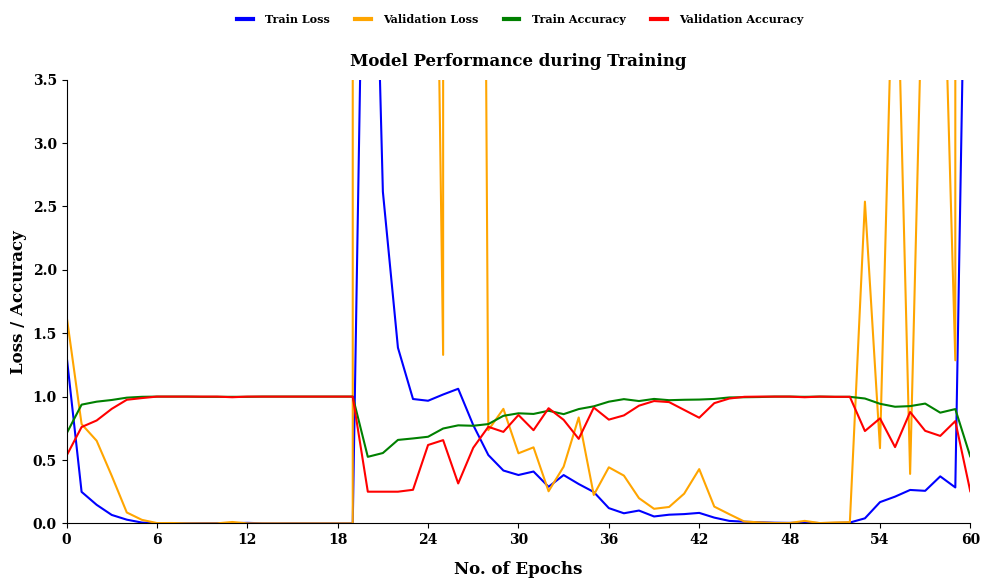

In [33]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerLine2D
import numpy as np
import os

# Create output directory
output_dir = '/kaggle/working/fundus_graphs'
os.makedirs(output_dir, exist_ok=True)

# Plot training & validation loss and accuracy values
plt.figure(figsize=(10, 6))

# Plot Loss and Accuracy
train_loss, = plt.plot(previous_history['loss'], label='Train Loss', color='blue')
val_loss, = plt.plot(previous_history['val_loss'], label='Validation Loss', color='orange')
train_accuracy, = plt.plot(previous_history['accuracy'], label='Train Accuracy',  color='green')
val_accuracy, = plt.plot(previous_history['val_accuracy'], label='Validation Accuracy', color='red')

# Add a title with font properties
plt.title('Model Performance during Training', fontdict={'family': 'Serif', 'weight': 'bold', 'size': 12}, pad=10)

# Set x-axis and y-axis labels
plt.xlabel('No. of Epochs', fontdict={'family': 'Serif', 'weight': 'bold', 'size': 12})
plt.ylabel('Loss / Accuracy', fontdict={'family': 'Serif', 'weight': 'bold', 'size': 12})

# Set x and y ticks
plt.xticks(np.linspace(0, 60, num=11), fontname='Serif', weight='bold')
plt.yticks(np.linspace(0, 4, num=9), fontname='Serif', weight='bold')

# Set axis limits
plt.xlim(0, 60)
plt.ylim(0, 3.5)

# Custom legend lines
legend_lines = [
    Line2D([0], [0], color='blue', lw=3),      # Train Loss
    Line2D([0], [0], color='orange', lw=3),    # Validation Loss
    Line2D([0], [0], color='green', lw=3),     # Train Accuracy
    Line2D([0], [0], color='red', lw=3)        # Validation Accuracy
]

# Add legend
plt.legend(
    legend_lines,
    ['Train Loss', 'Validation Loss', 'Train Accuracy', 'Validation Accuracy'],
    loc='lower center',
    bbox_to_anchor=(0.5, 1.1),
    ncol=5,
    prop={'family': 'Serif', 'weight': 'bold', 'size': 8},
    frameon=False,
    handler_map={Line2D: HandlerLine2D(numpoints=5)}
)

# Improve layout and appearance
plt.gca().xaxis.labelpad = 10
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()

# Save the figure
plt.savefig(os.path.join(output_dir, 'resnet50_accuracy_graph.pdf'))

# Show plot
plt.show()


In [34]:
# Assuming 'model' is your trained model
model.save('/kaggle/working/fundus_ResNet50/cp.weights.h5')

In [35]:
# Evaluate the model on the test dataset
loss, accuracy = loaded_model.evaluate(test_images, test_numeric_labels)

# Print the evaluation metrics (loss and accuracy)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.4306 - loss: 3.7338
Test Loss: 3.773587226867676
Test Accuracy: 0.46000000834465027


In [36]:
# Make predictions on the test dataset
predictions = loaded_model.predict(test_images)

# Get predicted labels (convert from numeric to string labels using inverse mapping)
inverse_label_map = {v: k for k, v in label_map.items()}
predicted_labels = [inverse_label_map[np.argmax(pred)] for pred in predictions]
# Print test and predicted labels
for i in range(len(test_labels)):
    print(f"Test Label: {test_labels[i]}, Predicted Label: {predicted_labels[i]}")

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_531']
Received: inputs=Tensor(shape=(32, 224, 224, 3))
  warnings.warn(msg)


5/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_531']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 938ms/step
Test Label: D, Predicted Label: A
Test Label: G, Predicted Label: G
Test Label: N, Predicted Label: G
Test Label: N, Predicted Label: D
Test Label: A, Predicted Label: D
Test Label: D, Predicted Label: D
Test Label: G, Predicted Label: G
Test Label: D, Predicted Label: D
Test Label: N, Predicted Label: G
Test Label: D, Predicted Label: G
Test Label: A, Predicted Label: A
Test Label: N, Predicted Label: G
Test Label: A, Predicted Label: G
Test Label: N, Predicted Label: D
Test Label: D, Predicted Label: A
Test Label: N, Predicted Label: D
Test Label: D, Predicted Label: A
Test Label: N, Predicted Label: G
Test Label: A, Predicted Label: A
Test Label: D, Predicted Label: D
Test Label: D, Predicted Label: D
Test Label: N, Predicted Label: D
Test Label: D, Predicted Label: A
Test Label: G, Predicted Label: D
Test Label: D, Predicted Label: A
Test Label: G, Predicted Label: G
Test Label: G, Predicted Label: G
Test Label: A, Predicted Label: A
Test Lab

In [37]:
print("\nClassification Report:")
print(classification_report(test_labels, predicted_labels,digits=4))


Classification Report:
              precision    recall  f1-score   support

           A     0.5176    0.8800    0.6519        50
           D     0.3654    0.3800    0.3725        50
           G     0.4237    0.5000    0.4587        50
           N     1.0000    0.0800    0.1481        50

    accuracy                         0.4600       200
   macro avg     0.5767    0.4600    0.4078       200
weighted avg     0.5767    0.4600    0.4078       200



In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, jaccard_score,roc_auc_score

# Assuming predicted_probs contains the probabilities for each class

predicted_probs = model.predict(test_images)
# Calculate Accuracy
accuracy = accuracy_score(test_labels, predicted_labels)
print(f"Accuracy: {accuracy}")

# Calculate Precision, Recall, F1 Score
precision = precision_score(test_labels, predicted_labels, average='weighted')
print(f"Precision: {precision}")

recall = recall_score(test_labels, predicted_labels, average='weighted')
print(f"Recall: {recall}")

f1 = f1_score(test_labels, predicted_labels, average='weighted')
print(f"F1 Score: {f1}")

# Calculate Jaccard Score
jaccard = jaccard_score(test_labels, predicted_labels, average='weighted')
print(f"Jaccard Score: {jaccard}")

logloss = log_loss(test_numeric_labels, predicted_probs)
print(f"Log Loss: {logloss}")

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_354']
Received: inputs=Tensor(shape=(32, 224, 224, 3))
  warnings.warn(msg)


5/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_354']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 665ms/step
Accuracy: 0.46
Precision: 0.5766901219418668
Recall: 0.46
F1 Score: 0.4078161539845296
Jaccard Score: 0.2725127984465334
Log Loss: 2.211858843394924


In [39]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode string labels ('A', 'D', 'G', 'N') to numeric labels
numeric_test_labels = label_encoder.fit_transform(test_labels)

# Calculate ROC AUC score using One-vs-Rest (ovr) strategy
roc_auc_ovr = roc_auc_score(numeric_test_labels, predicted_probs, multi_class='ovr')
print(f"ROC AUC Score (One-vs-Rest): {roc_auc_ovr}")

# Calculate ROC AUC score using One-vs-One (ovo) strategy
roc_auc_ovo = roc_auc_score(numeric_test_labels, predicted_probs, multi_class='ovo')
print(f"ROC AUC Score (One-vs-One): {roc_auc_ovo}")

ROC AUC Score (One-vs-Rest): 0.9252333333333334
ROC AUC Score (One-vs-One): 0.9252333333333332


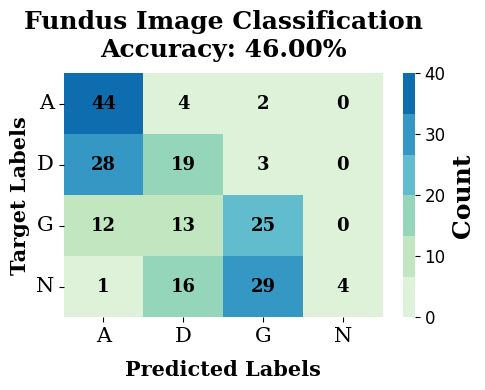

In [40]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
conf_matrix = confusion_matrix(test_labels, predicted_labels)
# Calculate accuracy
accuracy = accuracy_score(test_labels, predicted_labels)
accuracy_percentage = accuracy * 100
# Plot confusion matrix
plt.figure(figsize=(5, 4))
# Define the custom palette
custom_palette = sns.color_palette(palette='GnBu')# Modify the number based on number of classes in the dataset
# Define custom font dictionary for title and labels
font = {'family': 'Serif', 'weight': 'bold', 'size': 18}
font2 = {'family': 'Serif', 'weight': 'bold', 'size': 15}

# Create heatmap with annotations and colormap
heatmap = sns.heatmap(conf_matrix, annot=True, fmt='d', cmap=custom_palette,vmin = 0,vmax = 40,
                      xticklabels=['A', 'D', 'G', 'N'], yticklabels=['A', 'D', 'G', 'N'],
                      annot_kws={"family": "Serif", 'color':'black','weight': 'bold', 'size': 13})

# Set x and y labels with the custom font dictionary
heatmap.set_xlabel('Predicted Labels', fontdict=font2)
heatmap.set_ylabel('Target Labels', fontdict=font2)
heatmap.set_title('Fundus Image Classification\nAccuracy: {:.2f}%'.format(accuracy_percentage),fontdict=font, pad=12)
#heatmap.set_title('Lung and colon Classification', fontdict=font, pad=12)
# Set font properties for tick labels on both axes
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontname='Serif', fontsize=15)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontname='Serif', fontsize=15)

# Create a color bar to indicate the scale
cbar = heatmap.collections[0].colorbar
cbar.set_label('Count', fontdict=font)
cbar.ax.tick_params(labelsize=12)
# Adjust padding between x-axis label and x-axis ticks
plt.gca().xaxis.labelpad = 10  # Change the value as needed to adjust the space
plt.xticks(rotation=0)
plt.yticks(rotation=0)
# Adjust layout to prevent cropping
plt.tight_layout()
plt.savefig('D:\Data\\fundus_graphs\\ResNet50_confusion_matrix.pdf')  # Save as pdf format
plt.show()